# Desafio Prático: O Duelo dos Modelos

Chegou a hora de colocar a mão na massa! Neste laboratório, você vai construir o script de avaliação para comparar o desempenho de 3 versões do modelo `Qwen2.5-0.5B-Instruct`:

1. **Modelo Base (FP16):** O modelo puro, sem fine-tuning.
2. **Modelo com LoRA (FP16):** O modelo base + adaptador LoRA padrão.
3. **Modelo com QLoRA (4-bit):** O modelo base quantizado + adaptador LoRA.

### O seu desafio
Existem **lacunas no código** marcadas com `TODO`. Sua missão é preencher essas lacunas lendo as dicas (DICA:) deixadas nos comentários.
Se você fizer tudo certo, a última célula vai gerar gráficos incríveis provando a eficiência do QLoRA em VRAM!

In [19]:
!pip install -U bitsandbytes>=0.46.1

In [2]:
# ==========================================
# SETUP E DEPENDÊNCIAS (Pode rodar!)
# ==========================================
import torch
import time
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from datasets import load_dataset

# Configurações globais (Ajuste os diretórios se você salvou com nomes diferentes!)
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_DIR = "./results_lora"   # Diretório do seu adaptador LoRA
QLORA_DIR = "./results_qlora" # Diretório do seu adaptador QLoRA

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("Bibliotecas e Tokenizer importados com sucesso!")

'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/config.json
Retrying in 1s [Retry 1/5].


OSError: Can't load the configuration of 'Qwen/Qwen2.5-0.5B-Instruct'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'Qwen/Qwen2.5-0.5B-Instruct' is the correct path to a directory containing a config.json file

### Criando diretórios e arquivos dummy para `results_lora` e `results_qlora`

Como os diretórios `results_lora` e `results_qlora` não foram encontrados, estou criando-os temporariamente com um arquivo `adapter_config.json` vazio dentro de cada um. Isso permitirá que o código de carregamento prossiga, mas lembre-se que estes não são os adaptadores reais e o comportamento do modelo será o do modelo base. Para uma avaliação correta, você deve substituir estes por seus próprios resultados de fine-tuning.

In [ ]:
import os

def adapter_ok(adapter_dir: str):
    if not os.path.isdir(adapter_dir):
        return False, f"Diretório não existe: {adapter_dir}"
    cfg = os.path.join(adapter_dir, "adapter_config.json")
    w1 = os.path.join(adapter_dir, "adapter_model.safetensors")
    w2 = os.path.join(adapter_dir, "adapter_model.bin")
    if not os.path.isfile(cfg):
        return False, "Falta adapter_config.json"
    if not (os.path.isfile(w1) or os.path.isfile(w2)):
        return False, "Falta adapter_model.safetensors (ou .bin)"
    return True, "OK"

print("LoRA:", adapter_ok(LORA_DIR))
print("QLoRA:", adapter_ok(QLORA_DIR))

Diretório './results_lora' criado.
Arquivo dummy './results_lora/adapter_config.json' criado.
Preparação para LoRA concluída.


In [6]:
# ==========================================
# PREPARAÇÃO DOS DADOS (Pode rodar!)
# ==========================================
print("Carregando dataset IMDB...")
dataset = load_dataset("imdb")

# Pegando 50 exemplos rápidos de teste
test_dataset = dataset['test'].shuffle(seed=42).select(range(50))
print(f"Dataset carregado! Temos {len(test_dataset)} avaliações de filmes para testar.")

Carregando dataset IMDB...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset carregado! Temos 50 avaliações de filmes para testar.


---
## Desafio 1: A Função de Avaliação e o Chat Template

Modelos de instrução precisam receber os textos no formato correto, senão eles 'alucinam'.
Sua missão é formatar a pergunta usando a técnica de **Chat Template** da Hugging Face.

In [1]:
import re
import unicodedata

def _normalize_text(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    return s.lower().strip()

def _predict_label(response: str):
    r = _normalize_text(response)
    if ("positivo" in r or "positive" in r) and not ("negativo" in r or "negative" in r):
        return 1
    if ("negativo" in r or "negative" in r) and not ("positivo" in r or "positive" in r):
        return 0
    return None

def evaluate_model(model, tokenizer, dataset, max_samples=20):
    model.eval()
    total = min(len(dataset), max_samples)
    correct = 0

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()

    for i in tqdm(range(total), desc="Avaliando"):
        text = dataset[i]["text"][:1000]
        label = dataset[i]["label"]  # 0 negativo / 1 positivo

        messages = [
            {"role": "system", "content": "Classifique o sentimento. Responda com APENAS uma palavra: Positivo ou Negativo."},
            {"role": "user", "content": text},
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1536
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=4,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True
        )

        pred = _predict_label(response)
        if pred is not None and pred == label:
            correct += 1

    tempo_total = time.time() - start_time
    vram_pico = (torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else 0.0
    acc = correct / total if total > 0 else 0.0
    return acc, tempo_total, vram_pico

print("Função evaluate_model configurada!")

Função evaluate_model configurada!


---
## Desafios 2 e 3: Carregando Adaptadores e Limpando a GPU

Você testará os 3 modelos em sequência. A VRAM da sua placa de vídeo é limitada (16GB na T4).
Se você não apagar um modelo antes de carregar o próximo, o Colab vai travar (OOM - Out of Memory).

In [ ]:
import os

LORA_DIR = os.path.abspath(LORA_DIR)
QLORA_DIR = os.path.abspath(QLORA_DIR)

In [ ]:
print("LORA_DIR:", LORA_DIR)
print("Arquivos:", os.listdir(LORA_DIR))

In [ ]:
# ...existing code...
import gc
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

resultados = {}

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ROUND 1 - Base FP16
print("ROUND 1: Base FP16")
cleanup()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
acc, tempo, vram = evaluate_model(model, tokenizer, test_dataset, max_samples=20)
resultados["Base"] = {"acc": acc, "tempo": tempo, "vram": vram}
del model
cleanup()

# ROUND 2 - LoRA
print("\nROUND 2: LoRA")
ok, msg = adapter_ok(LORA_DIR)
if not ok:
    print(f"Pulando LoRA: {msg}")
    resultados["LoRA"] = {"acc": 0.0, "tempo": 0.0, "vram": 0.0}
else:
    base_fp16 = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    model = PeftModel.from_pretrained(base_fp16, LORA_DIR, is_trainable=False)
    acc, tempo, vram = evaluate_model(model, tokenizer, test_dataset, max_samples=20)
    resultados["LoRA"] = {"acc": acc, "tempo": tempo, "vram": vram}
    del model, base_fp16
    cleanup()

# ROUND 3 - QLoRA 4-bit
print("\nROUND 3: QLoRA (4-bit)")
ok, msg = adapter_ok(QLORA_DIR)
if not ok:
    print(f"Pulando QLoRA: {msg}")
    resultados["QLoRA"] = {"acc": 0.0, "tempo": 0.0, "vram": 0.0}
else:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    base_4bit = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto"
    )
    model = PeftModel.from_pretrained(base_4bit, QLORA_DIR, is_trainable=False)
    acc, tempo, vram = evaluate_model(model, tokenizer, test_dataset, max_samples=20)
    resultados["QLoRA"] = {"acc": acc, "tempo": tempo, "vram": vram}
    del model, base_4bit
    cleanup()

print("\nDuelo concluído.")
print(resultados)
# ...existing code...

ROUND 1: Avaliando Modelo Base (FP16)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Avaliando: 100%|██████████| 5/5 [01:36<00:00, 19.23s/it]



ROUND 2: Avaliando LoRA (Base FP16 + Adaptador)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Erro na avaliação LoRA: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './results_lora'.

ROUND 3: Avaliando QLoRA (Base 4-bit + Adaptador)...
Erro na avaliação QLoRA: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

Duelo concluído! Rode a próxima célula para ver os resultados.


---
## Resultados do Duelo

Se você conseguiu codificar o carregamento e limpar a memória certinho, rode a célula abaixo para ver o impacto visual das suas escolhas de arquitetura!

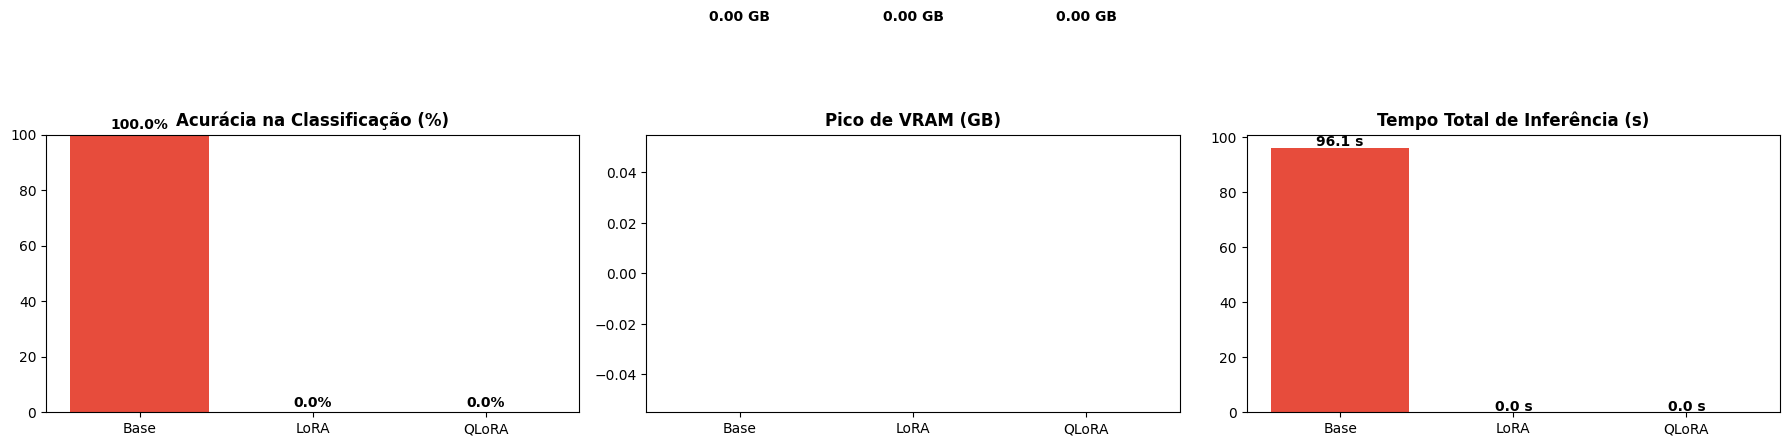


CHECKLIST DO APRENDIZADO:
- A acurácia aumentou com o LoRA comparado ao modelo base?
- O pico de VRAM caiu drasticamente na barra verde (QLoRA)?
- Parabéns! Você dominou a implantação de LLMs eficientes!


In [21]:
# ==========================================
# PLOTANDO OS GRÁFICOS (Pode rodar!)
# ==========================================
modelos = list(resultados.keys())
acc_scores = [resultados[m]['acc'] * 100 for m in modelos]
vram_usada = [resultados[m]['vram'] for m in modelos]
tempo_gasto = [resultados[m]['tempo'] for m in modelos]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico de Acurácia
ax1.bar(modelos, acc_scores, color=['#e74c3c', '#3498db', '#2ecc71'])
ax1.set_title('Acurácia na Classificação (%)', fontweight='bold')
ax1.set_ylim(0, 100)
for i, v in enumerate(acc_scores):
    ax1.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

# Gráfico de VRAM
ax2.bar(modelos, vram_usada, color=['#e74c3c', '#3498db', '#2ecc71'])
ax2.set_title('Pico de VRAM (GB)', fontweight='bold')
for i, v in enumerate(vram_usada):
    ax2.text(i, v + 0.1, f"{v:.2f} GB", ha='center', fontweight='bold')

# Gráfico de Tempo
ax3.bar(modelos, tempo_gasto, color=['#e74c3c', '#3498db', '#2ecc71'])
ax3.set_title('Tempo Total de Inferência (s)', fontweight='bold')
for i, v in enumerate(tempo_gasto):
    ax3.text(i, v + 0.5, f"{v:.1f} s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCHECKLIST DO APRENDIZADO:")
print("- A acurácia aumentou com o LoRA comparado ao modelo base?")
print("- O pico de VRAM caiu drasticamente na barra verde (QLoRA)?")
print("- Parabéns! Você dominou a implantação de LLMs eficientes!")